In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import pandas as pd

df1 = pd.read_csv("lcdm_chains_minusmu.csv")
df2 = pd.read_csv("gp_chains_minusmu.csv")

In [3]:
f1 = df1.filter(regex="hz_model").values
g1 = df1.filter(regex="fs8_model").values
f2 = df2.filter(regex="hz_mod").values
g2 = df2.filter(regex="fs8_mod").values

print(f2.shape, g2.shape)

(500, 300) (500, 300)


In [4]:
# stack the two functions
X_lcdm = np.hstack([f1, g1])   
X_gp = np.hstack([f2, g2])     
# full correlation matrix
corr_full_LCDM = np.corrcoef(X_lcdm, rowvar=False)
corr_full_GP = np.corrcoef(X_gp, rowvar=False)

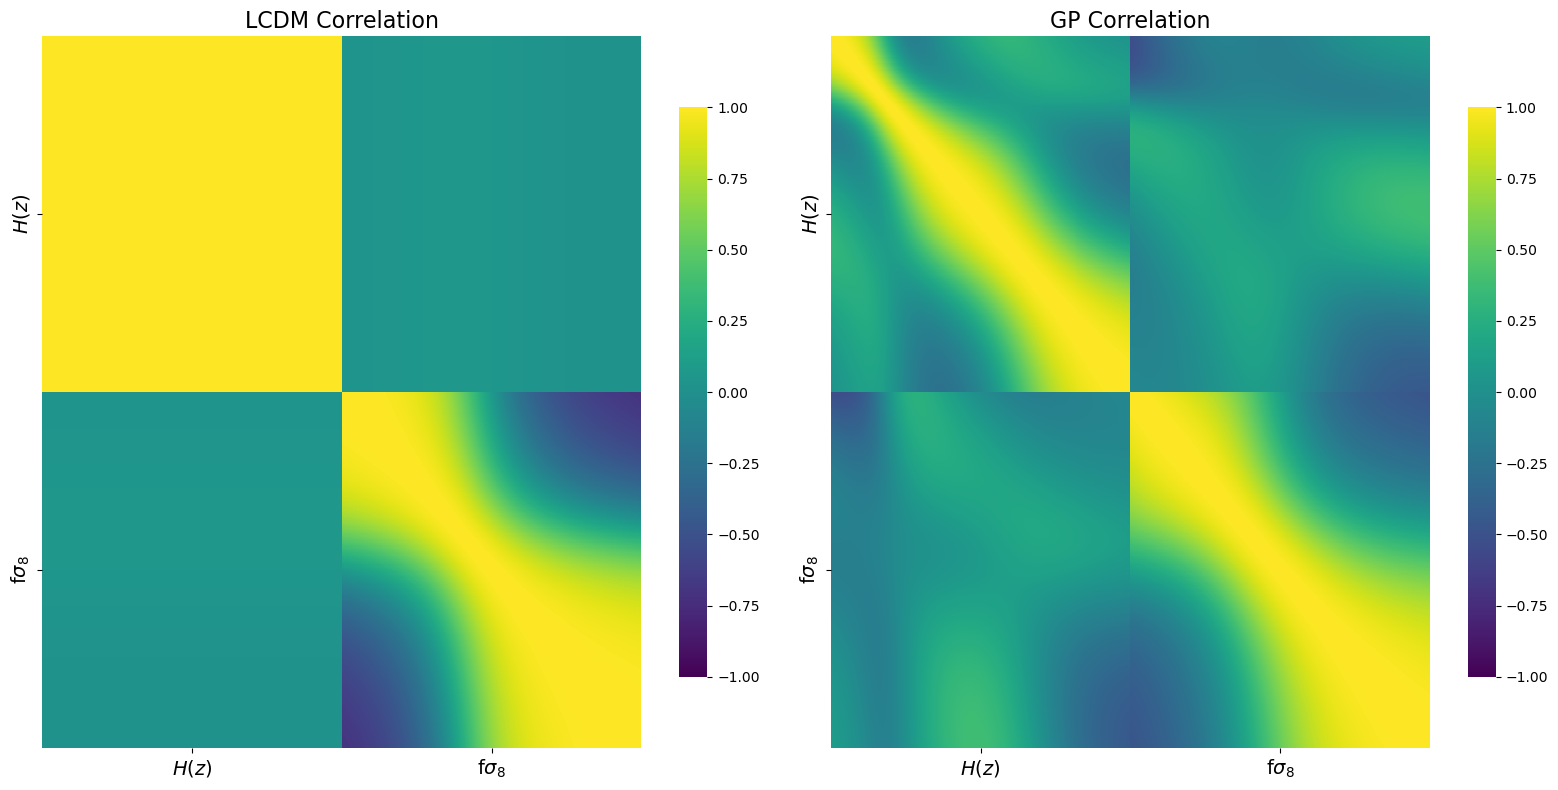

In [5]:

import matplotlib
# matplotlib.use("pdf")
# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8))

# --- Left plot: LCDM correlation ---
sns.heatmap(corr_full_LCDM, cmap="viridis", vmin=-1, vmax=1, ax=ax1, cbar_kws={'shrink':0.8})
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticks([150, 450])
ax1.set_xticklabels([r'$H(z)$', r'f$\sigma_8$'], rotation=0, fontsize=14)
ax1.set_yticks([150, 450])
ax1.set_yticklabels([r'$H(z)$', r'f$\sigma_8$'], rotation=90, fontsize=14)
ax1.set_title("LCDM Correlation", fontsize=16)

# --- Right plot: GP correlation ---
sns.heatmap(corr_full_GP, cmap="viridis", vmin=-1, vmax=1, ax=ax2, cbar_kws={'shrink':0.8})
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticks([150, 450])
ax2.set_xticklabels([r'$H(z)$', r'f$\sigma_8$'], rotation=0, fontsize=14)
ax2.set_yticks([150, 450])
ax2.set_yticklabels([r'$H(z)$', r'f$\sigma_8$'], rotation=90, fontsize=14)
ax2.set_title("GP Correlation", fontsize=16)

plt.tight_layout()
# plt.savefig("correlations_alldata.pdf", bbox_inches='tight')
# plt.close()
plt.show()